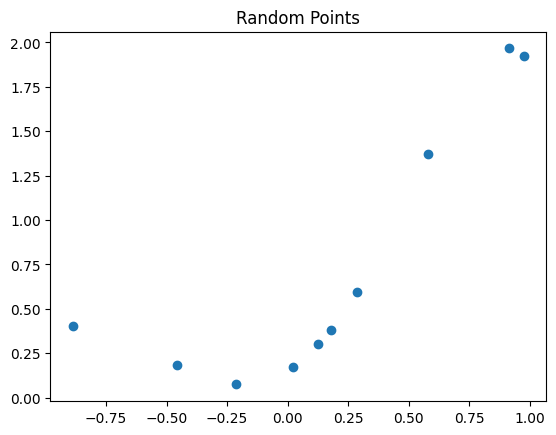

In [560]:
import numpy as np
import matplotlib.pyplot as plt
dof = 10
x = np.random.randn(dof)/2 # np.arange(10)
def make_polynomial(vector, _dof=None):
    if not _dof: _dof = dof
    b = vector.shape[0]
    return np.cumprod(np.concatenate([np.ones((b, 1)), vector.reshape(-1, 1).repeat(_dof-1, axis=1)], axis=1), axis=1)
Z = make_polynomial(x, 10)
d = Z @ np.random.randn(10)
plt.title("Random Points")
plt.scatter(x, d)

0.29261021988046704x^0+-1.87815850378365x^1+-0.4819755648922399x^2+1.9334838869229884x^3+2.472667685424842x^4+0.9679553481680777x^5+-1.723677194380537x^6+1.0386954817369947x^7+-0.25501452288750065x^8+2.2103157851847737x^9
loss(model).mean()=0.49704791935127435


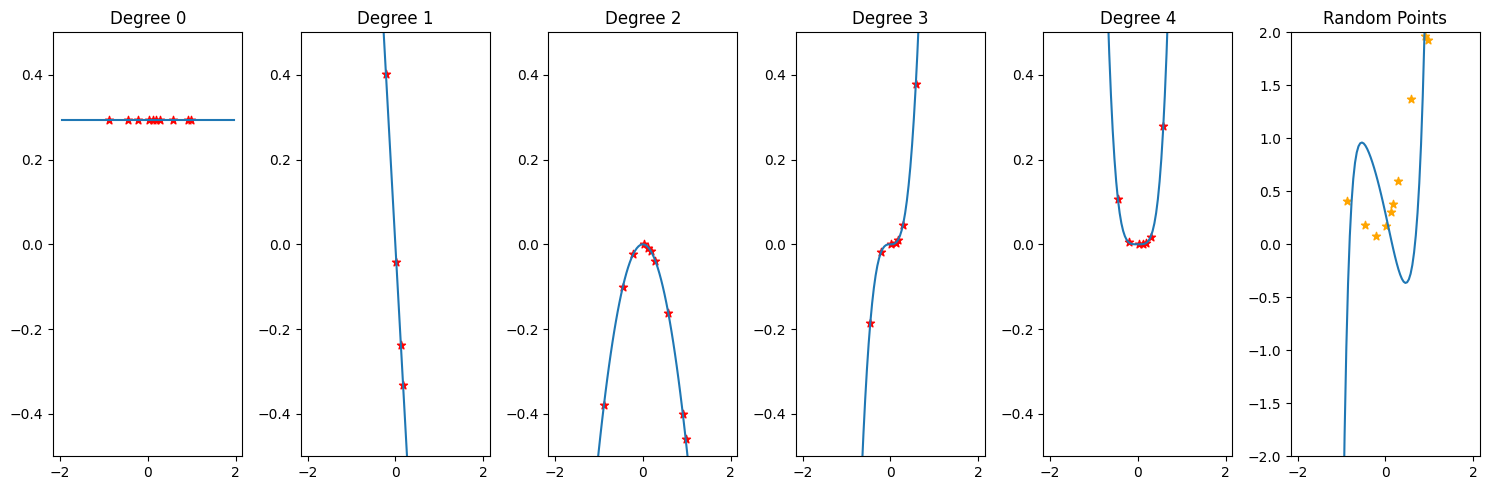

In [561]:
model = np.random.randn(dof)
print("+".join([f"{pi}x^{degree}" for degree, pi in enumerate(model)]))
def loss(model): return 0.5 * (Z @ model  - d) ** 2
print(f"{loss(model).mean()=}")

def make_polynomial_plot(model, x, d, dof=10, total_plots=5):
    fig, ax = plt.subplots(1, total_plots+1, figsize=(15, 5))
    space = np.linspace(-1.96, 1.96, 100) # 2sigma?
    for degree in range(dof)[:total_plots]:
        pi = model[degree]
        graph = space ** degree * pi
        ax[degree].plot(space, graph)
        ax[degree].scatter(x, pi * x ** degree, marker="*", color="r")
        ax[degree].set_title(f"Degree {degree}")
        ax[degree].set_ylim(-0.5, 0.5)
    ax[total_plots].set_title("Random Points")
    ax[total_plots].plot(space, make_polynomial(space, dof) @ model)
    ax[total_plots].scatter(x, d, marker="*", color="orange")
    ax[total_plots].set_ylim(-2, 2)
    fig.tight_layout()
    return

_ = make_polynomial_plot(model, x, d)

0.4222234681508657
0.11003933562451651
0.09050086400142482
0.08203443751223047
0.07515818650057883
0.06922171897493191
0.06397925125786891
0.05927555425831872
0.0550069945174387
0.051102287848610185
0.04751068915014698
0.044194642167961214
0.04112519142819181
0.038279108479693895
0.03563708289367464
0.03318257522782089
0.03090108213023527
0.028779658591848993
0.02680660115189577
0.024971232316839745


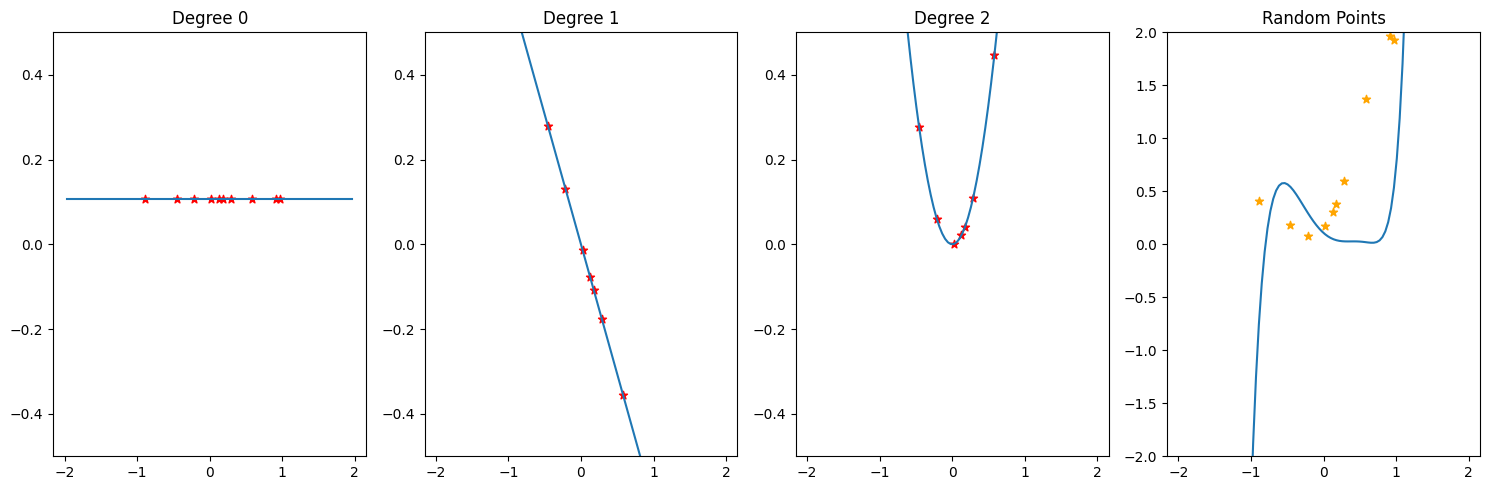

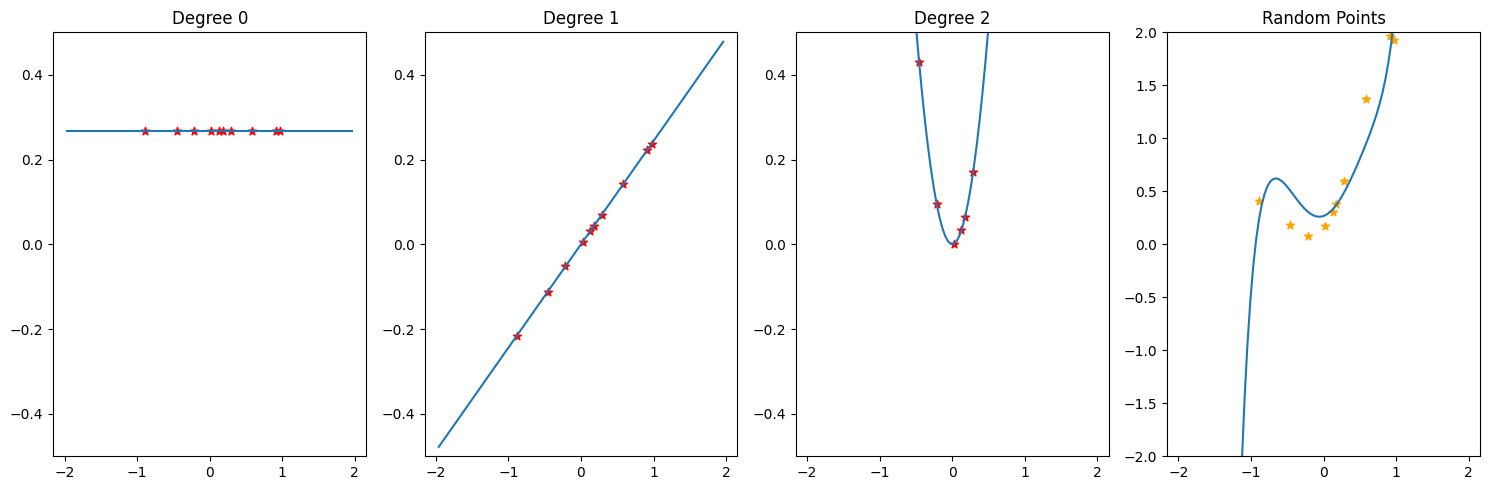

In [565]:
# minimize 1/2(model(Z)-d)^2
# dL/dw => below ((Z @ model - d) * Z).mean(axis=0)
model = np.random.randn(10)
alpha = 0.1
make_polynomial_plot(model, x, d, total_plots=3)
for i in range(200):
    if i % 10 == 0:
        print(loss(model).mean())
    model -= alpha * ((Z @ model - d).reshape(-1, 1) * Z).mean(axis=0)
make_polynomial_plot(model, x, d, total_plots=3)

**simplify the situation here, for getting insights.**

find the 1 degree of polynomial line crossing (0, 1) (1, 0).

$f(w) = 0.25 \times ((p_0-1)^2+(p_0+p_1-0)^2) = 0.5 \times w^T A w - b^Tw + C$

where, w=coeff; A=[[4, 2], [2, 2]]; b=[2, 0]

In [575]:
x = np.array([0, 1])
y = np.array([1, 0])
Z = make_polynomial(x, _dof=2)
w = np.random.randn(2) # coefficients of polynomial
A = np.array([[2, 1], [1, 1]]) / 2
b = np.array([1, 0]) / 2
Ainv = np.linalg.inv(A)
eigval, eigvec = np.linalg.eig(A) # Q \lambda Q^T -> ECA

As we get $\nabla f(w)=Aw-b$, $w^*=A^{-1}b$

In [524]:
w_optimal = Ainv @ b
w_optimal

array([ 1., -1.])

In [525]:
eigvec, eigval, eigvec.T @ eigvec

A @ eigvec, eigvec @ np.diag(eigval)

(array([[ 1.11351636, -0.10040571],
        [ 0.68819096,  0.16245985]]),
 array([[ 1.11351636, -0.10040571],
        [ 0.68819096,  0.16245985]]))

In [526]:
alpha = 0.1
w0 = w
x0 = eigvec.T @ (w0-w_optimal) # deformation along the eigvector
w1 = w0 - alpha * (A @ w0 - b)
x1 = eigvec.T @ (w1-w_optimal)
w2 = w1 - alpha * (A @ w1 - b)
x2 = eigvec.T @ (w2-w_optimal)

np.allclose(x0 * (1-alpha*eigval), x1), np.allclose(x0 * (1-alpha*eigval)**2, x2)

(True, True)

In [527]:
np.allclose(w1, w0 - alpha * ((Z @ w0 - y).reshape(-1, 1) * Z).mean(axis=0))

True

Text(0.5, 1.0, 'Exponential Shrink Rate')

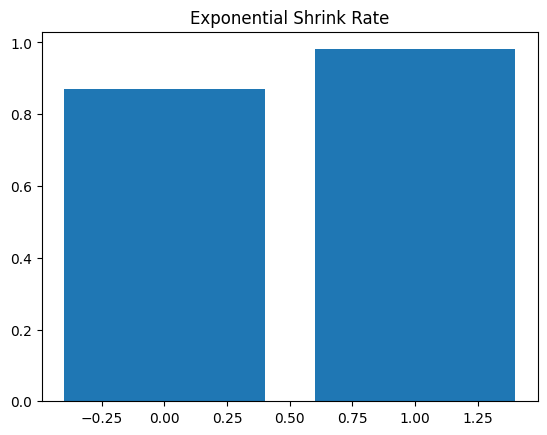

In [528]:
plt.bar(range(2), (1-alpha*eigval))
plt.title("Exponential Shrink Rate")

Text(0.5, 1.0, 'Exponential Shrink Rate, alpha is optimal')

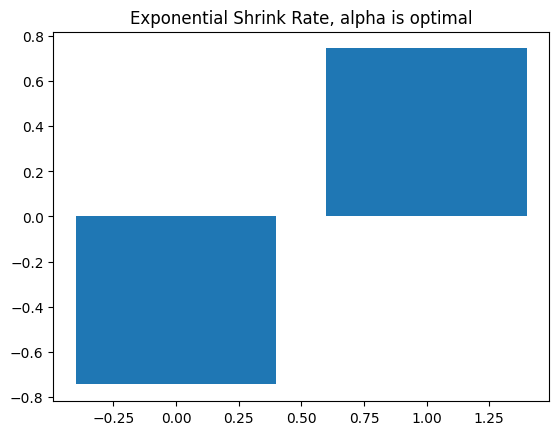

In [529]:
alpha_optimal = 2 / (eigval[0] + eigval[1])
plt.bar(range(2), (1-alpha_optimal*eigval))
plt.title("Exponential Shrink Rate, alpha is optimal")

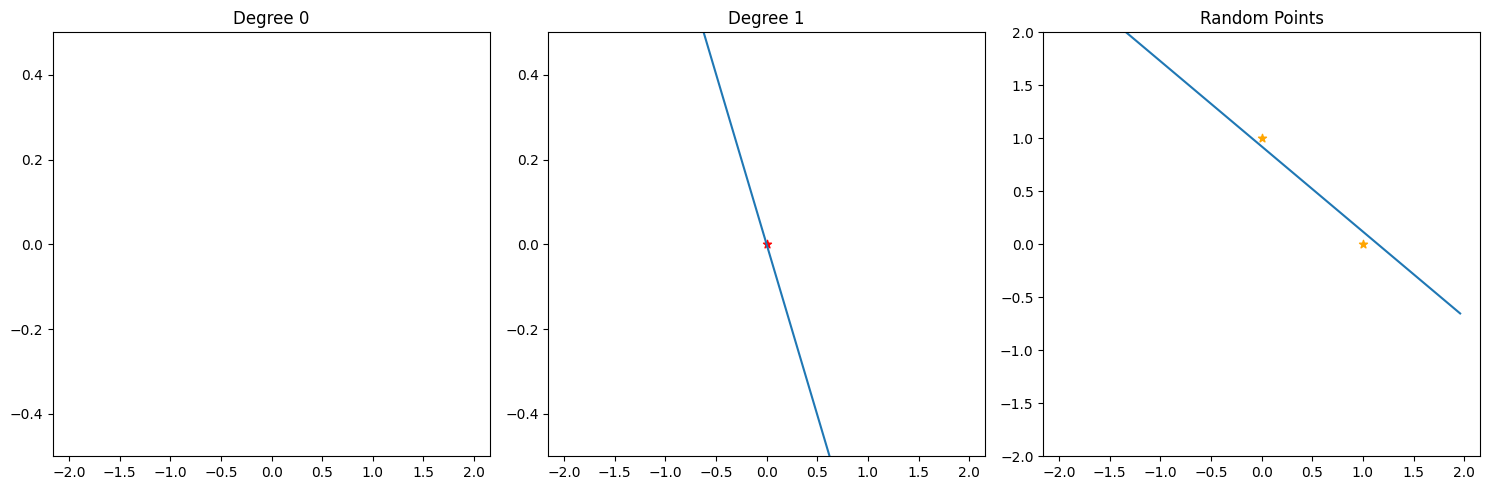

In [536]:
ww = w0.copy()
for i in range(7):
    ww -= alpha_optimal * (A @ ww - b)
make_polynomial_plot(ww, x, y, dof=2, total_plots=2)

**Extend to Nth polynomial data**

Following FFT's idea we get (n^2->nlogn), but we can do more with O(1). How is it possible? This is math not algorithm.

In 2 dimensional A, we can easily get a coeff landscape information. How to extend to N data points specified? -> 이항정리

- Calculate A, b ~ N^3
- Calculate Eigvector ~ QR Decomposition

We get kth gradient descent product with closed-form expression. Despite of some costy preparations... ORR Calculate the w_optimal for happiness!

In [679]:
dof = 10
x = np.random.randn(dof)/2
Z = make_polynomial(x, dof)
d = Z @ np.random.randn(10)

A = (Z.T @ Z) / dof
b = Z.T @ d / dof
eigval,eigvec = np.linalg.eig(A)
w_optimal = np.linalg.inv(A) @ b
np.allclose(eigvec @ np.diag(1/eigval) @ eigvec.T, np.linalg.inv(A))

False

In [688]:
(1-alpha_optimal*eigval)

array([-1.        ,  0.68561116,  0.9223207 ,  0.99613872,  0.99994872,
        0.99999931,  0.99999994,  1.        ,  1.        ,  1.        ])

Text(0.5, 1.0, 'Exponential Shrink Rate, blue: alpha is optimal')

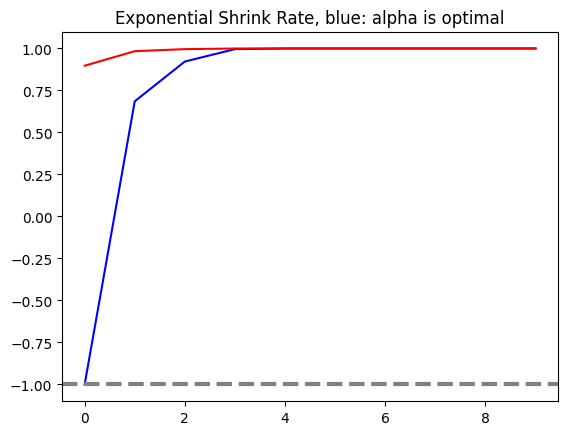

In [681]:
alpha_optimal = 2 / (eigval[0] + eigval[-1])
plt.plot(range(10), 1-alpha_optimal*eigval, color="b")
plt.plot(range(10), 1-0.1*eigval, color="r")
plt.axhline(-1, 0, 1, color='gray', linestyle='--', linewidth=3)
plt.title("Exponential Shrink Rate, blue: alpha is optimal")

In [682]:
w0 = np.random.randn(dof)
k = 5000
x0 = eigvec.T @ (w0-w_optimal) # deformation along the eigvector
xk = x0 * (1-alpha_optimal*eigval) ** k
wk = eigvec @ xk + w_optimal

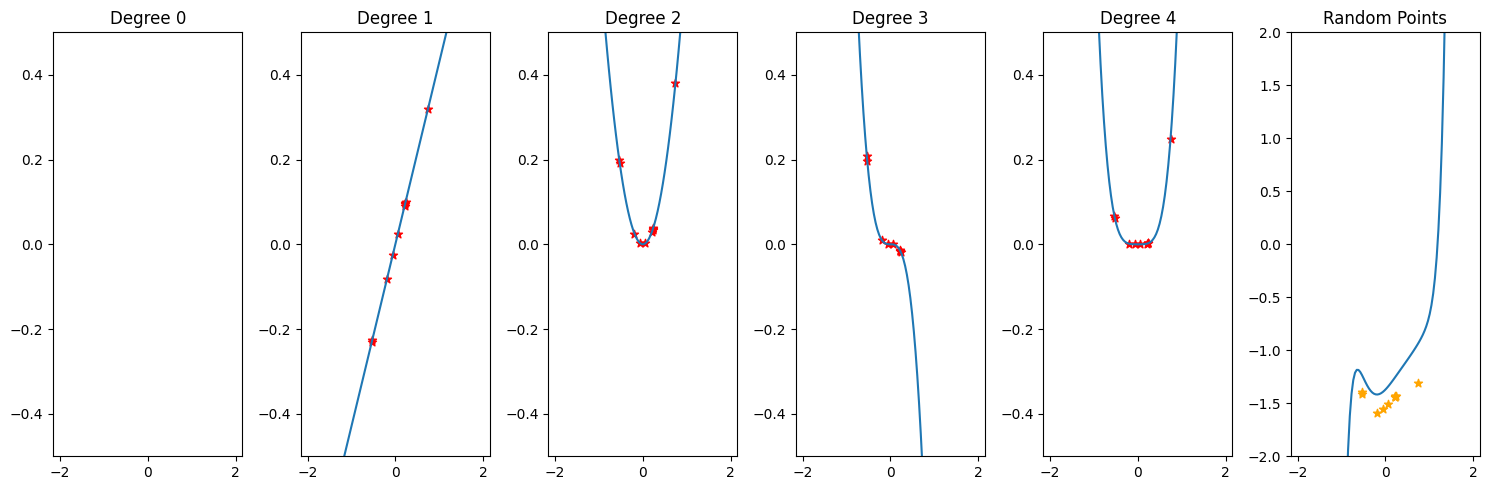

In [687]:
make_polynomial_plot(wk, x, d, dof)

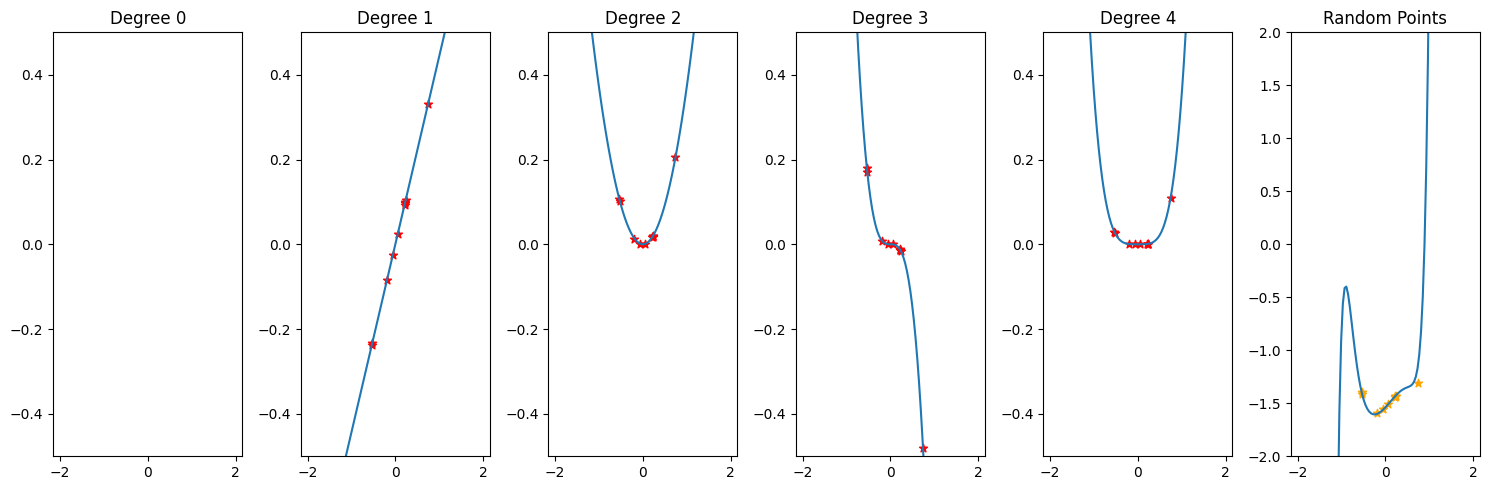

In [686]:
make_polynomial_plot(w_optimal, x, d, dof)